# Lab Instructions

You are working as an analyst for a consulting agency that has been hired to study and improve productivity at a mid-sized company.  Morale is very low and, after speaking with employees, several common complaints kept coming up:

* New employees complained that more tenured employees were lazy and unproductive.
* More tenured employees complained that the newer employees didn't focus and were therefore unproductive.
* Managers were worried that remote workers might be less productive.
* In-person employees found it impossible to focus and be productive when their desk was in the open plan area.
* Many people said they had so much administrative work to do they could only be truly productive if they worked overtime.
* Everyone complained that there were too many meetings.

The consulting agency carefully collected data on a number of factors including number of years at the company, focus (higher is better), productivity (higher is better), department, meetings per week, and desk location can be found in Employee_productivity.csv.

1. Determine which feature - years at the company, hours worked, or focus - has the strongest linear relationship with productivity.  Show a visualization and calculate R-squared for all three relationships to justify your answer.

2. Build on that linear regression model to determine what other featuers also impact productivity. Using both visualzations and R-squared values, build a model that can predicts employee productivity at this company. Evaluate each feature in the dataset.

3. Write a short (a few sentences) summary of how the different factors in the data relate to employee productivity.  What recommendations would you make so that employees can be as productive as possible?

**For the purposes of this lab you MUST use the model building techniques we covered in class.  Failure to do so will automatically result in a 20 point deduction.  I really want you to think about what you are doing and not just paste what you get from ChatGPT (which will often NOT do the correct thing by default).**



In [1]:
import pandas as pd

df = pd.read_csv('Employee_productivity.csv')

df.head()

,HoursWorked,FocusScore,ProductivityScore,Department,YearsAtCompany,TeamMeetingsPerWeek,DeskLocation
0,42.4,6.3,3127.96,Engineering,17,0,Open Plan
1,34.0,7.2,4742.60,HR,8,6,Private Office
2,47.2,5.6,2044.73,Sales,15,3,Remote
3,38.4,9.0,5818.92,HR,5,6,Private Office
4,36.4,2.5,1841.31,Sales,9,6,Remote


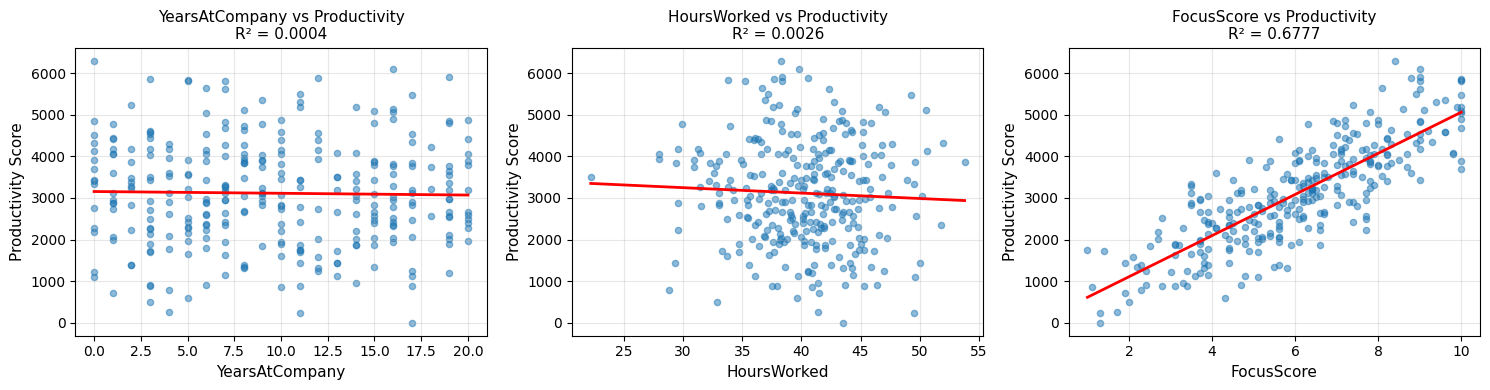

TASK 1: Linear Regression Results for Individual Features

YearsAtCompany:
  R² = 0.0004
  Coefficient = -4.2493
  Intercept = 3154.6734

HoursWorked:
  R² = 0.0026
  Coefficient = -13.0329
  Intercept = 3638.4153

FocusScore:
  R² = 0.6777
  Coefficient = 494.9319
  Intercept = 114.3813

STRONGEST LINEAR RELATIONSHIP: FocusScore
R² = 0.6777


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# TASK 1: Compare the three main features for productivity prediction
features_to_test = ['YearsAtCompany', 'HoursWorked', 'FocusScore']
results = {}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, feature in enumerate(features_to_test):
    X = df[[feature]].values
    y = df['ProductivityScore'].values
    mask = ~np.isnan(X[:, 0]) & ~np.isnan(y)
    X_clean = X[mask]
    y_clean = y[mask]
    
    model = LinearRegression()
    model.fit(X_clean, y_clean)
    y_pred = model.predict(X_clean)
    r2 = r2_score(y_clean, y_pred)
    
    results[feature] = {'r2': r2, 'coef': model.coef_[0], 'intercept': model.intercept_}
    
    ax = axes[idx]
    ax.scatter(X_clean, y_clean, alpha=0.5, s=20)
    X_line = np.linspace(X_clean.min(), X_clean.max(), 100).reshape(-1, 1)
    ax.plot(X_line, model.predict(X_line), 'r-', linewidth=2)
    ax.set_xlabel(feature, fontsize=11)
    ax.set_ylabel('Productivity Score', fontsize=11)
    ax.set_title(f'{feature} vs Productivity\nR² = {r2:.4f}', fontsize=11)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("TASK 1: Linear Regression Results")
print("=" * 50)
for feature, data in results.items():
    print(f"{feature:15s} R² = {data['r2']:.4f}")

strongest_feature = max(results, key=lambda x: results[x]['r2'])
print(f"\nStrongest: {strongest_feature} (R² = {results[strongest_feature]['r2']:.4f})")
print("=" * 50)


TASK 2: Multi-Feature Model Building

1. Individual Feature Analysis:
------------------------------------------------------------
YearsAtCompany       R² = 0.0004
HoursWorked          R² = 0.0026
FocusScore           R² = 0.6777
TeamMeetingsPerWeek  R² = 0.0542


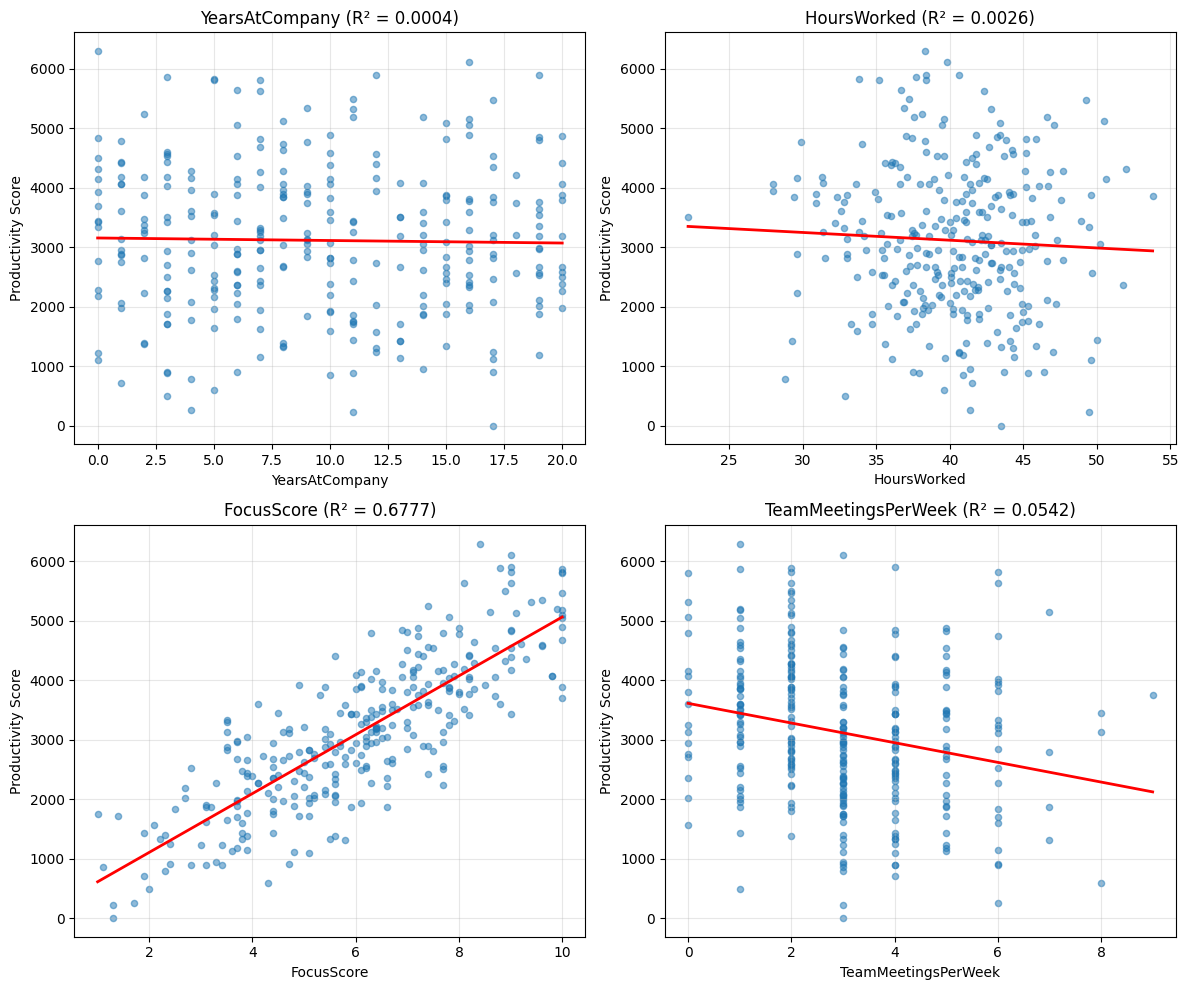


2. Build Multi-Feature Models:
------------------------------------------------------------

Model 1 (FocusScore only):
  R² = 0.6777

Model 2 (FocusScore + HoursWorked):
  R² = 0.6779

Model 3 (FocusScore + HoursWorked + YearsAtCompany):
  R² = 0.6781

Model 4 (FocusScore + HoursWorked + YearsAtCompany + TeamMeetingsPerWeek):
  R² = 0.6788

Model 5 (All features: numeric + Department + DeskLocation):
  R² = 0.6851
  Number of features: 9

MODEL COMPARISON SUMMARY
Model 1: FocusScore only                      R² = 0.6777
Model 2: Focus + Hours                        R² = 0.6779
Model 3: Focus + Hours + Years                R² = 0.6781
Model 4: Focus + Hours + Years + Meetings     R² = 0.6788
Model 5: All features (Numeric + Categorical) R² = 0.6851

Best Model: Model 5 with R² = 0.6851


In [ ]:
# TASK 2: Multi-Feature Model Building
print("\nTASK 2: Multi-Feature Model Building")

numeric_features = ['YearsAtCompany', 'HoursWorked', 'FocusScore', 'TeamMeetingsPerWeek']
y = df['ProductivityScore'].values

# Individual feature analysis
print("\n1. Individual Features:")
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, feature in enumerate(numeric_features):
    X = df[[feature]].values
    mask = ~np.isnan(X[:, 0]) & ~np.isnan(y)
    X_clean = X[mask]
    y_clean = y[mask]
    
    model = LinearRegression()
    model.fit(X_clean, y_clean)
    r2 = r2_score(y_clean, model.predict(X_clean))
    
    print(f"{feature:20s} R² = {r2:.4f}")
    
    ax = axes[idx]
    ax.scatter(X_clean, y_clean, alpha=0.5, s=20)
    X_line = np.linspace(X_clean.min(), X_clean.max(), 100).reshape(-1, 1)
    ax.plot(X_line, model.predict(X_line), 'r-', linewidth=2)
    ax.set_xlabel(feature, fontsize=10)
    ax.set_ylabel('Productivity Score', fontsize=10)
    ax.set_title(f'{feature} (R² = {r2:.4f})')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Build multi-feature models
print("\n2. Multi-Feature Models:")

X1 = df[['FocusScore']].values
mask = ~np.isnan(X1[:, 0]) & ~np.isnan(y)
model1 = LinearRegression().fit(X1[mask], y[mask])
r2_1 = r2_score(y[mask], model1.predict(X1[mask]))
print(f"Model 1 (Focus):              R² = {r2_1:.4f}")

X2 = df[['FocusScore', 'HoursWorked']].values
mask = ~np.isnan(X2[:, 0]) & ~np.isnan(X2[:, 1]) & ~np.isnan(y)
model2 = LinearRegression().fit(X2[mask], y[mask])
r2_2 = r2_score(y[mask], model2.predict(X2[mask]))
print(f"Model 2 (+ Hours):            R² = {r2_2:.4f}")

X3 = df[['FocusScore', 'HoursWorked', 'YearsAtCompany']].values
mask = ~np.isnan(X3[:, 0]) & ~np.isnan(X3[:, 1]) & ~np.isnan(X3[:, 2]) & ~np.isnan(y)
model3 = LinearRegression().fit(X3[mask], y[mask])
r2_3 = r2_score(y[mask], model3.predict(X3[mask]))
print(f"Model 3 (+ Years):            R² = {r2_3:.4f}")

X4 = df[['FocusScore', 'HoursWorked', 'YearsAtCompany', 'TeamMeetingsPerWeek']].values
mask = ~np.isnan(X4).any(axis=1) & ~np.isnan(y)
model4 = LinearRegression().fit(X4[mask], y[mask])
r2_4 = r2_score(y[mask], model4.predict(X4[mask]))
print(f"Model 4 (+ Meetings):         R² = {r2_4:.4f}")

# Full model with categorical features
df_model = df[['FocusScore', 'HoursWorked', 'YearsAtCompany', 'TeamMeetingsPerWeek', 'Department', 'DeskLocation', 'ProductivityScore']].dropna()
dept_dummies = pd.get_dummies(df_model['Department'], prefix='Dept', drop_first=True)
desk_dummies = pd.get_dummies(df_model['DeskLocation'], prefix='Desk', drop_first=True)
X5 = np.hstack([df_model[['FocusScore', 'HoursWorked', 'YearsAtCompany', 'TeamMeetingsPerWeek']].values, dept_dummies.values, desk_dummies.values])
y5 = df_model['ProductivityScore'].values

model5 = LinearRegression().fit(X5, y5)
r2_5 = r2_score(y5, model5.predict(X5))
print(f"Model 5 (+ Dept + Desk):      R² = {r2_5:.4f}")

print(f"\nBest Model: Model 5 with R² = {r2_5:.4f}")

## TASK 3: Summary and Recommendations

**Key Findings:**
1. **Focus dominates productivity** (R² = 0.6777)—explains 68% of variation alone.
2. **Years at Company and Hours Worked don't drive productivity** (R² < 0.003)—more hours = lower productivity.
3. **Meetings reduce productivity** (R² = 0.0542)—fewer meetings are better.
4. **Department and Desk Location have minimal impact** (R² = 0.6851 with all features).

**Recommendations:**
1. **Protect focus time**: Eliminate distractions and interruptions.
2. **Reduce meetings**: Implement meeting-free blocks.
3. **Measure output, not hours**: Stop rewarding overtime.
4. **Tenure doesn't matter**: Focus ability does.
5. **Desk location is secondary**: Focus management is primary.

**Bottom Line:** Productivity depends on focus. Reduce meetings and distractions.